# **Seat Analysis**
 
Seat-level metrics for one run. Each seat is plotted separately.
 
## **Setup**
 
### **Imports**

In [1]:
import pathlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from cambench.eval import (
  win_rate,
  win_rate_trajectory,
  belief_accuracy,
  belief_accuracy_trajectory,
  hidden_rate,
  hidden_rate_trajectory,
  role_counts,
  assassination,
)

ROOT = pathlib.Path.cwd().parent  # notebooks/ -> project root
RUNS = ROOT / "data" / "runs"
RUN_DIR = str(sorted(RUNS.iterdir())[-1])  # latest run; or set one explicitly
WINDOW = 10  # rolling window for trajectories

plt.rcParams["xtick.labelsize"] = 8  # small tick labels so long seat keys fit
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["figure.titlesize"] = 16  # suptitle larger than subplot titles
print("RUN_DIR:", RUN_DIR)

RUN_DIR: /Users/luozihyuan/Developer/camelot-bench/data/runs/260911142213-0700


### **Helpers**


In [2]:
def cell_frame(result, get, group="overall"):
  """DataFrame of means: single group -> Series-like column; else seats x groups.
  `get(cell) -> (mean, ci_low, ci_high)` extracts the stat from a result cell."""
  if group == "overall":
    return pd.Series({seat: get(groups["overall"])[0] for seat, groups in result.items()}).sort_index()
  return pd.DataFrame({seat: {g: get(st)[0] for g, st in groups.items()} for seat, groups in result.items()}).T.sort_index()


def ci_err(result, get, frame):
  """Asymmetric error bars matching `frame`. For a Series -> [[lower],[upper]];
  for a grouped DataFrame -> {group: [[lower],[upper]]}."""

  def pair(cell):
    m, lo, hi = get(cell)
    return m - lo, hi - m

  if isinstance(frame, pd.Series):
    lows, highs = [], []
    for seat in frame.index:
      l, h = pair(result[seat]["overall"])
      lows.append(l)
      highs.append(h)
    return [lows, highs]
  yerr = {}
  for g in frame.columns:
    lows, highs = [], []
    for seat in frame.index:
      cell = result.get(seat, {}).get(g)
      l, h = pair(cell) if cell else (0.0, 0.0)
      lows.append(l)
      highs.append(h)
    yerr[g] = [lows, highs]
  return yerr


# extractors: pull (mean, ci_low, ci_high) from a cell
WIN = lambda c: (c["win_rate"], c["ci_low"], c["ci_high"])


def SCORE(metric):  # belief/hidden: nested under exact/align
  return lambda c: (c[metric]["mean"], c[metric]["ci_low"], c[metric]["ci_high"])


def bars(df, title, ylabel, ax=None, yerr=None):
  own = ax is None
  ax = df.plot(
    kind="bar",
    ax=ax,
    figsize=(13, 6.5) if own else None,
    yerr=yerr,
    capsize=3,
    width=0.75,
    error_kw={"alpha": 0.15},
    title=title,
    ylabel=ylabel,
    ylim=(0, 1.05),
    rot=0,
  )
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  for c in ax.containers:
    if hasattr(c, "datavalues"):
      ax.bar_label(c, labels=[f"{v:.0%}" for v in c.datavalues], label_type="center", fontsize=8)
  if ax.get_legend_handles_labels()[1]:
    ax.legend(loc="upper right")
  if own:
    plt.tight_layout()
    plt.show()


def match_bars(result, suptitle, grouped=False):
  """Two stacked panels (exact on top, align below). `grouped` splits each panel
  by side/role; otherwise one bar per seat with a 95% CI."""
  fig, axes = plt.subplots(2, 1, figsize=(13, 13))
  fig.suptitle(suptitle)
  for ax, metric in zip(axes, ["exact", "align"]):
    name = {"exact": "Exact", "align": "Alignment"}[metric]
    get = SCORE(metric)
    frame = cell_frame(result, get, group=None if grouped else "overall")
    bars(frame.fillna(0) if grouped else frame, name, metric, ax=ax, yerr=ci_err(result, get, frame))
  plt.tight_layout()
  plt.show()

## **Role Assignment**
 
How many times each seat was dealt each role, as a fairness check on the random
assignment.

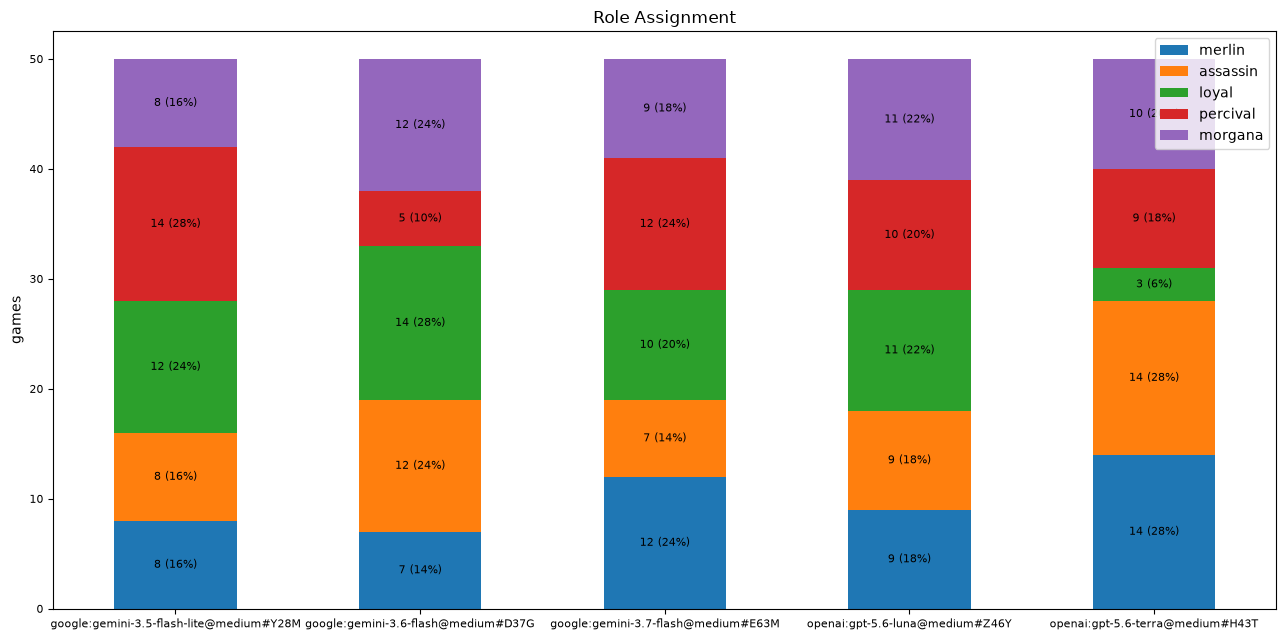

In [3]:
rc = pd.DataFrame(role_counts(RUN_DIR)).T.fillna(0).astype(int).sort_index()
totals = rc.sum(axis=1)
ax = rc.plot(kind="bar", stacked=True, figsize=(13, 6.5), title="Role Assignment", ylabel="games", rot=0)
for role, container in zip(rc.columns, ax.containers):
  labels = [f"{c} ({c / t:.0%})" if c else "" for c, t in zip(rc[role], totals)]
  ax.bar_label(container, labels=labels, label_type="center", fontsize=8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## **Win Rate**
 
Per seat, with Wilson 95% confidence intervals. Differences are meaningful only
where the intervals do not overlap.
 
### **Overall**

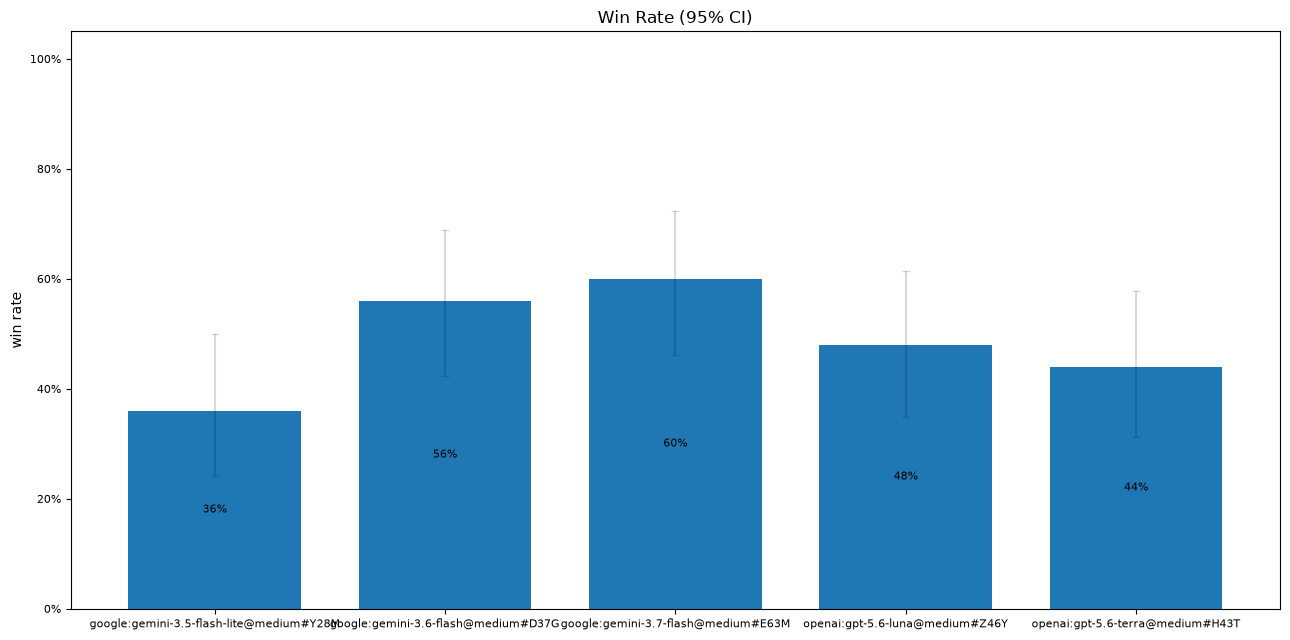

In [4]:
wr = win_rate(RUN_DIR)
frame = cell_frame(wr, WIN)
bars(frame, "Win Rate (95% CI)", "win rate", yerr=ci_err(wr, WIN, frame))

### **By Side**

Win rate split by the side each seat played (good vs. evil).

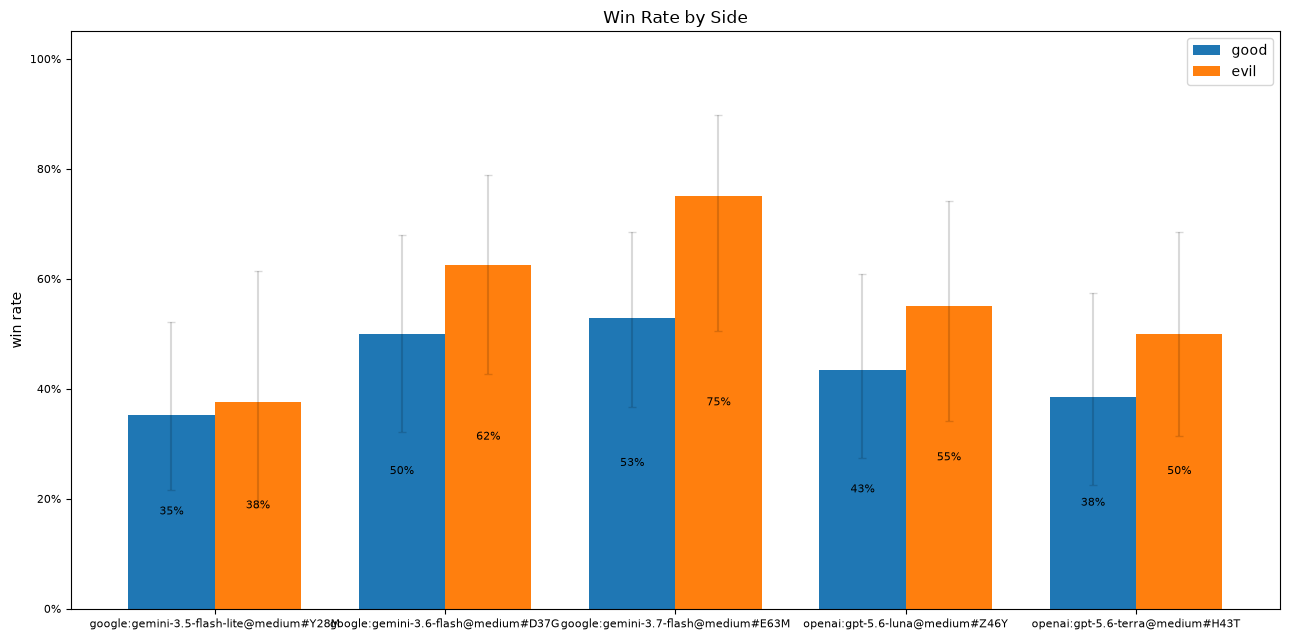

In [5]:
wr = win_rate(RUN_DIR, by="side")
frame = cell_frame(wr, WIN, group=None)
bars(frame.fillna(0), "Win Rate by Side", "win rate", yerr=ci_err(wr, WIN, frame))

### **By Role**

Win rate split by the role each seat played.

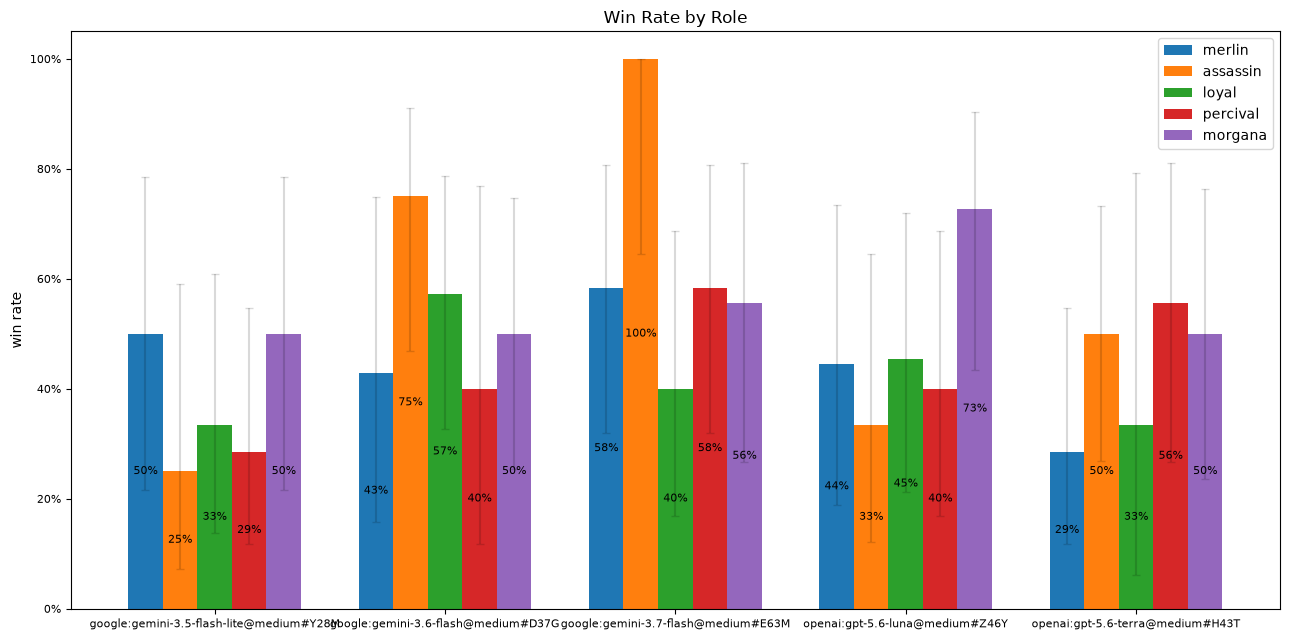

In [6]:
wr = win_rate(RUN_DIR, by="role")
frame = cell_frame(wr, WIN, group=None)
bars(frame.fillna(0), "Win Rate by Role", "win rate", yerr=ci_err(wr, WIN, frame))

## **Guess Accuracy**
 
Accuracy of each seat's role guesses (`exact`) and alignment guesses (`align`). Unguessed eligible targets are counted as incorrect.
 
### **Overall**

**Exact** counts naming a player's precise role. **Alignment** only counts getting their side (good/evil) right.

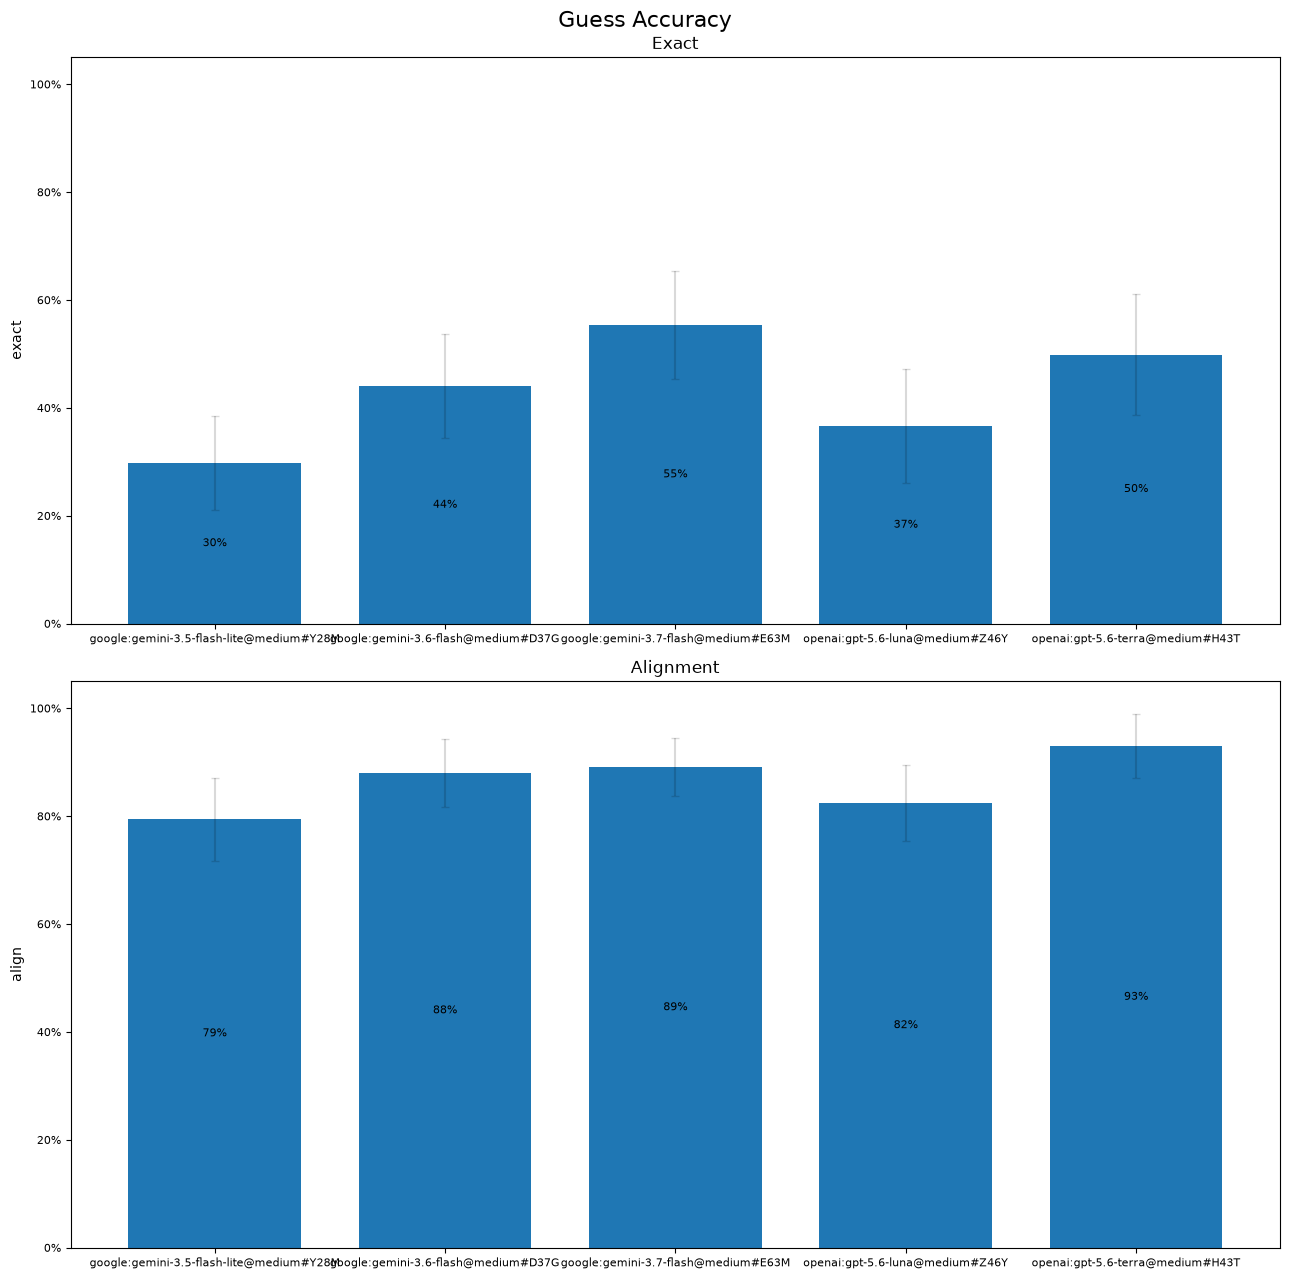

In [7]:
match_bars(belief_accuracy(RUN_DIR), "Guess Accuracy")

### **By Side**

Guess accuracy split by the guesser's own side (exact = precise role, alignment = side only).

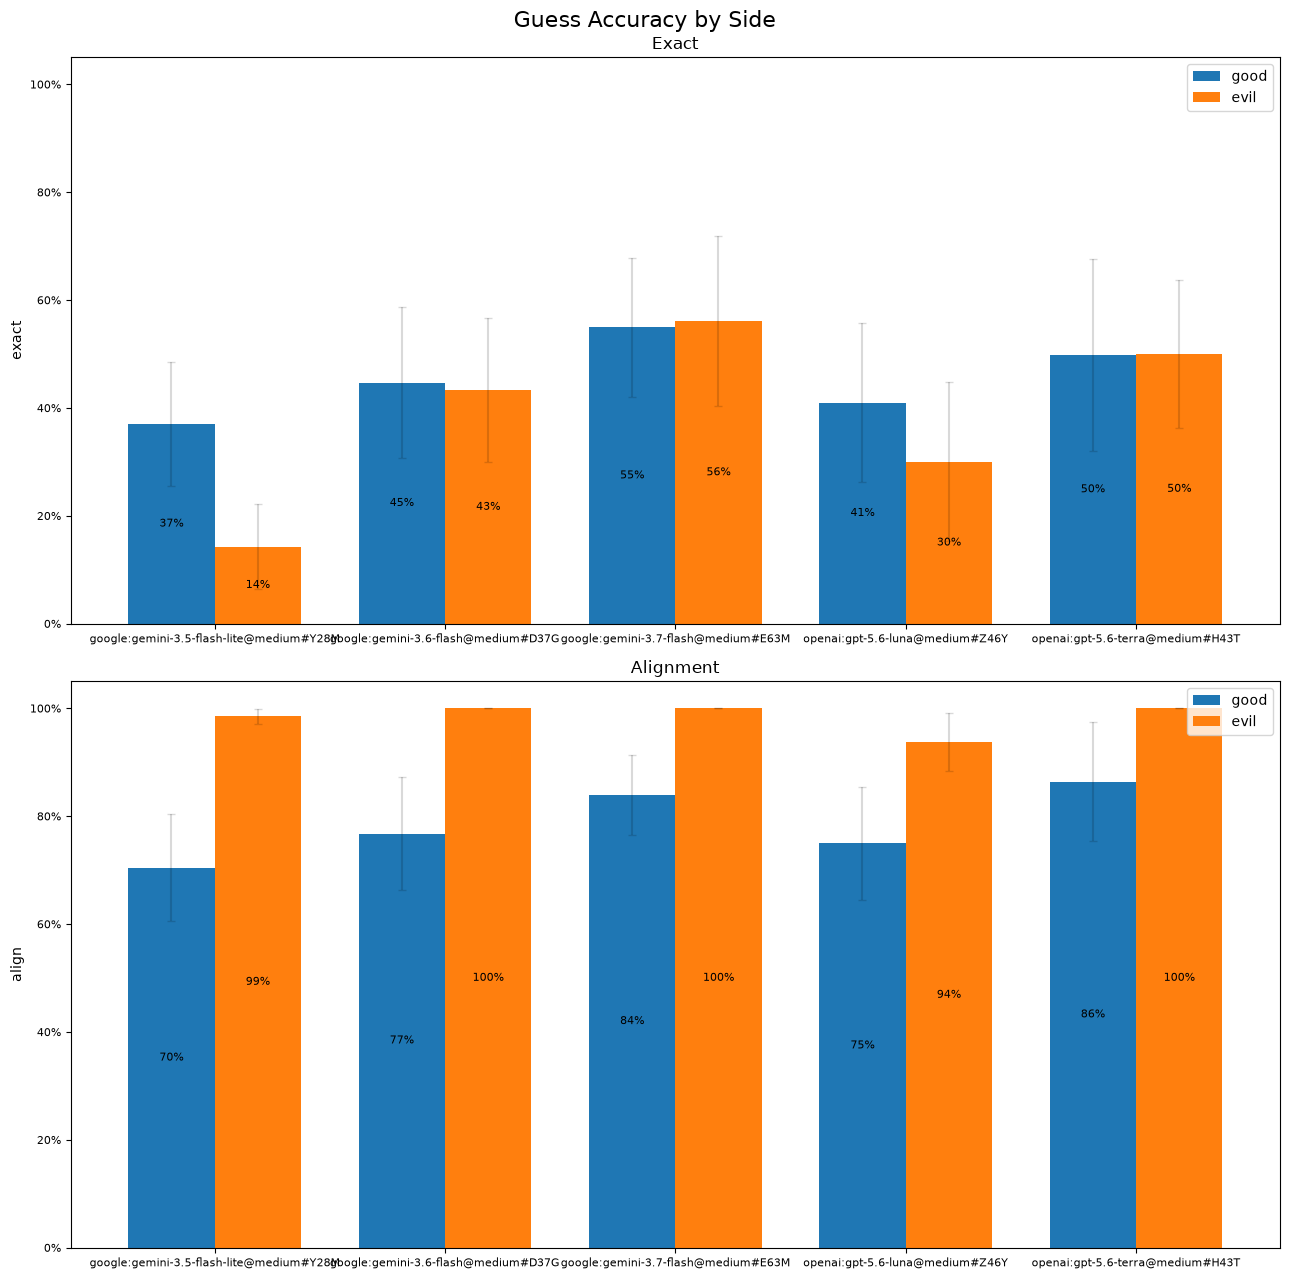

In [8]:
match_bars(belief_accuracy(RUN_DIR, by="side"), "Guess Accuracy by Side", grouped=True)

### **By Role**

Guess accuracy split by the guesser's own role (exact = precise role, alignment = side only).

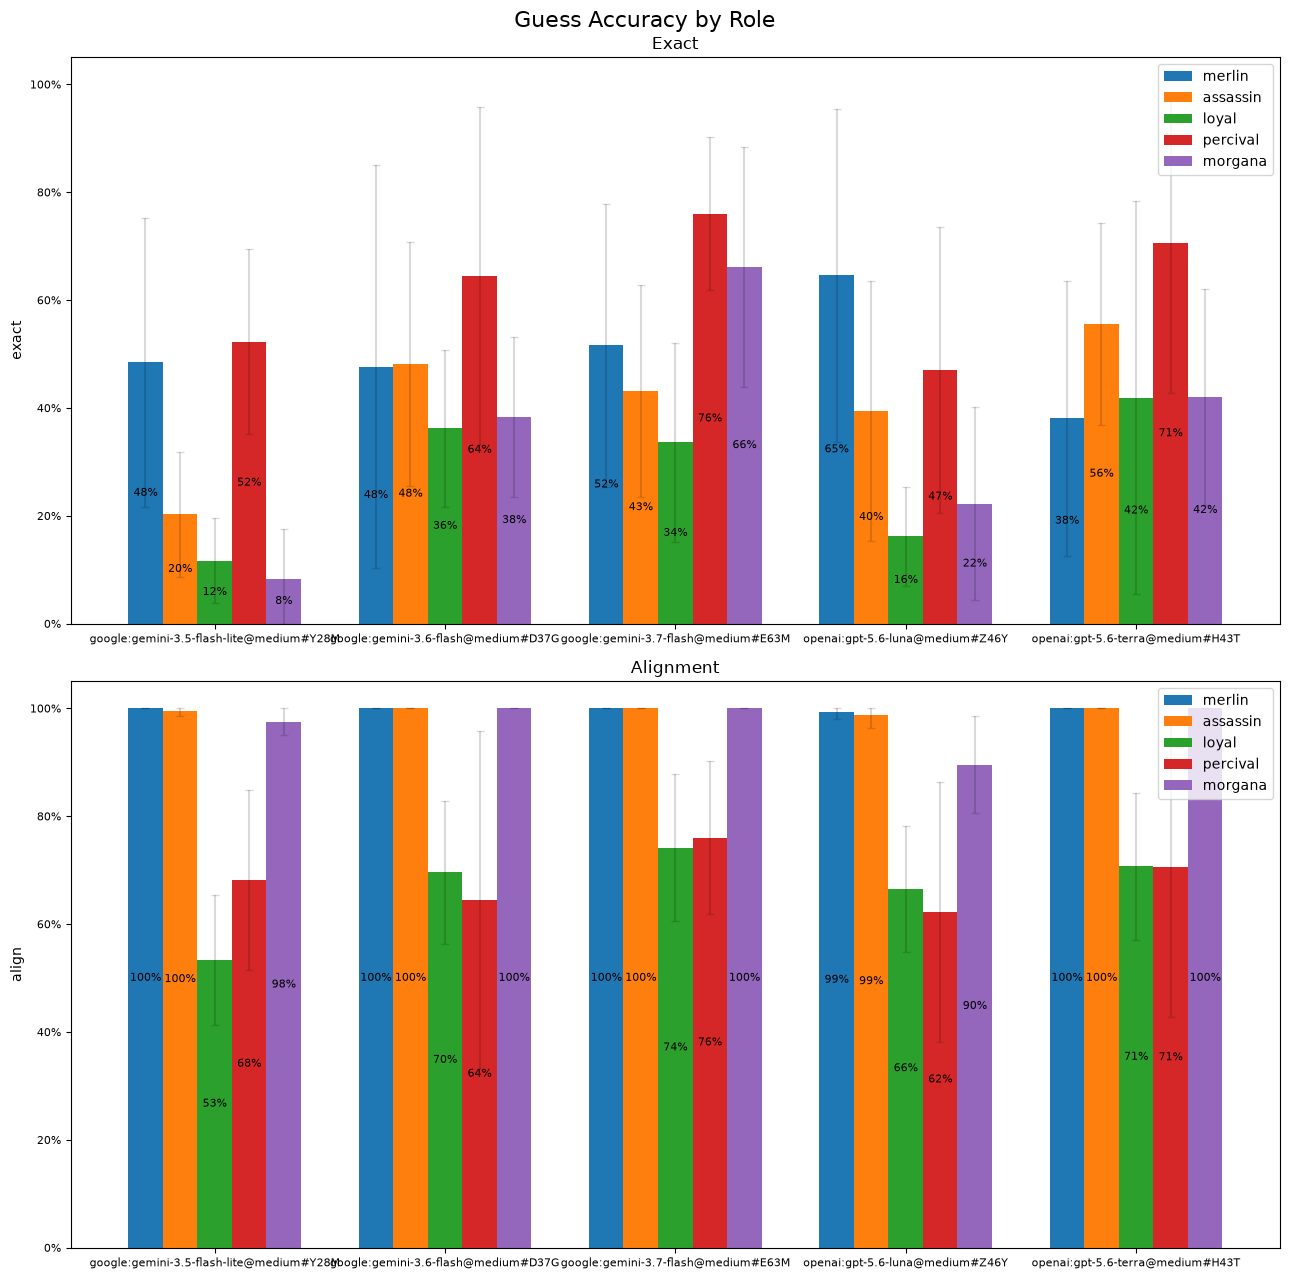

In [9]:
match_bars(belief_accuracy(RUN_DIR, by="role"), "Guess Accuracy by Role", grouped=True)

## **Hidden Rate**
 
How often other seats fail to identify each seat. Higher values indicate a seat that is harder to identify (for example, a well-concealed Merlin).
 
### **Overall**

**Exact** is how often others fail to name the seat's precise role. **Alignment** is how often they fail even to get its side.

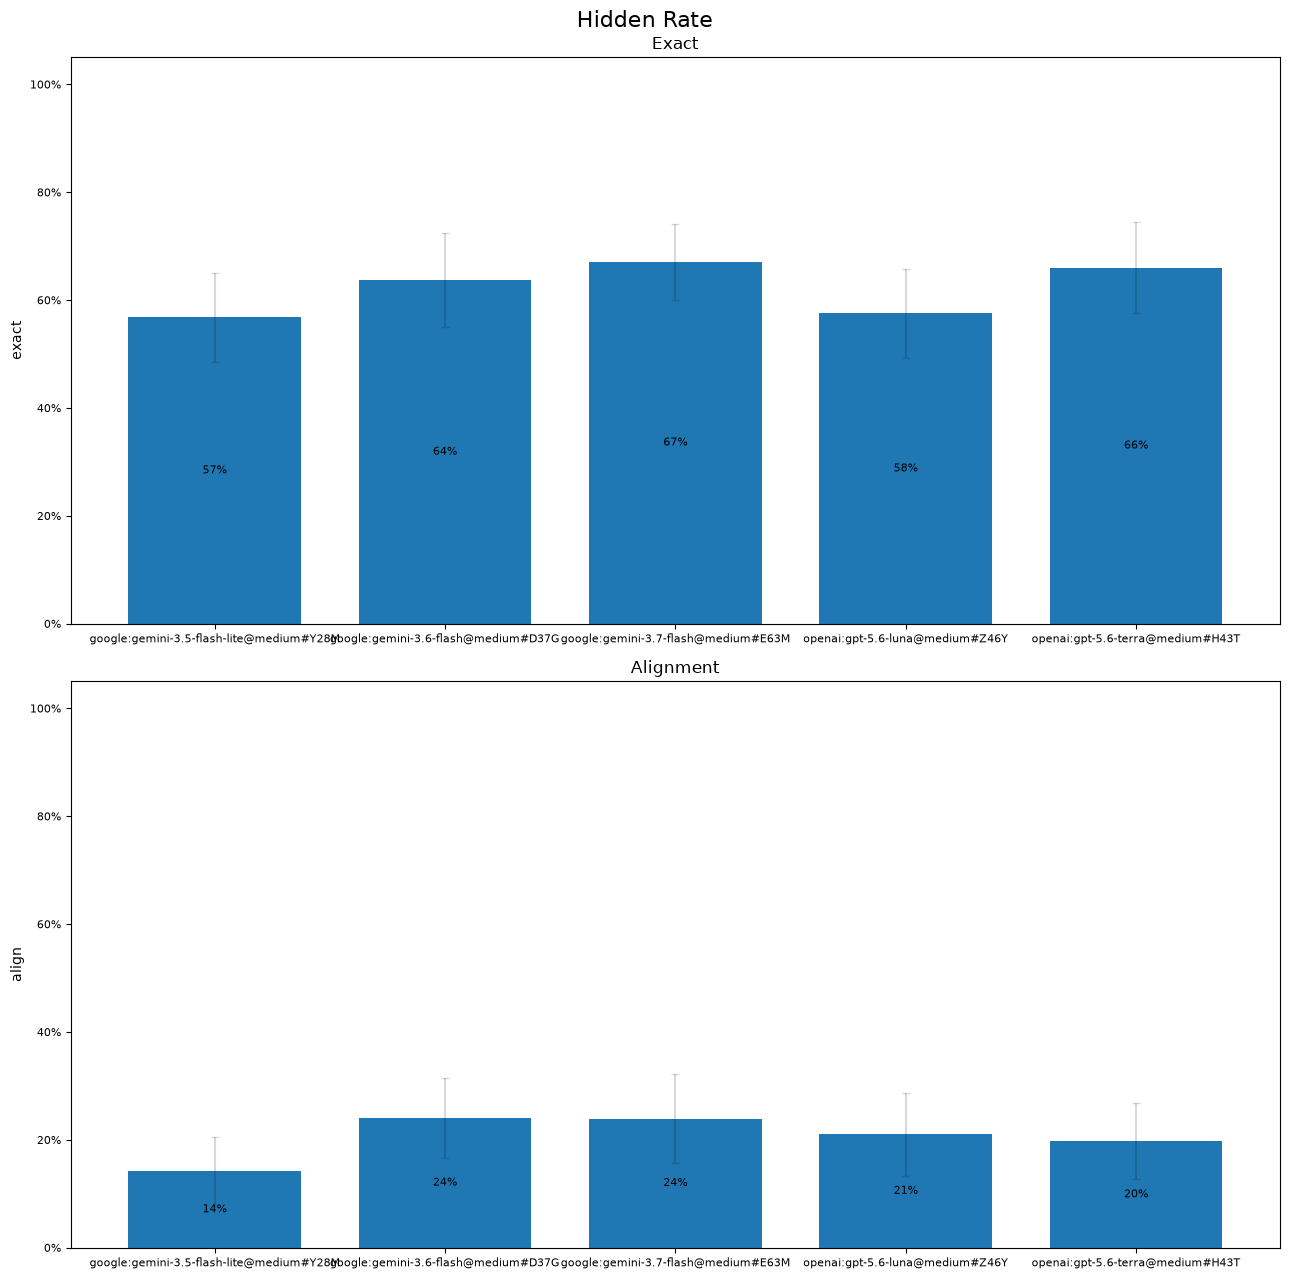

In [10]:
match_bars(hidden_rate(RUN_DIR), "Hidden Rate")

### **By Side**

Hidden rate split by the seat's own side (exact = precise role hidden, alignment = side hidden).

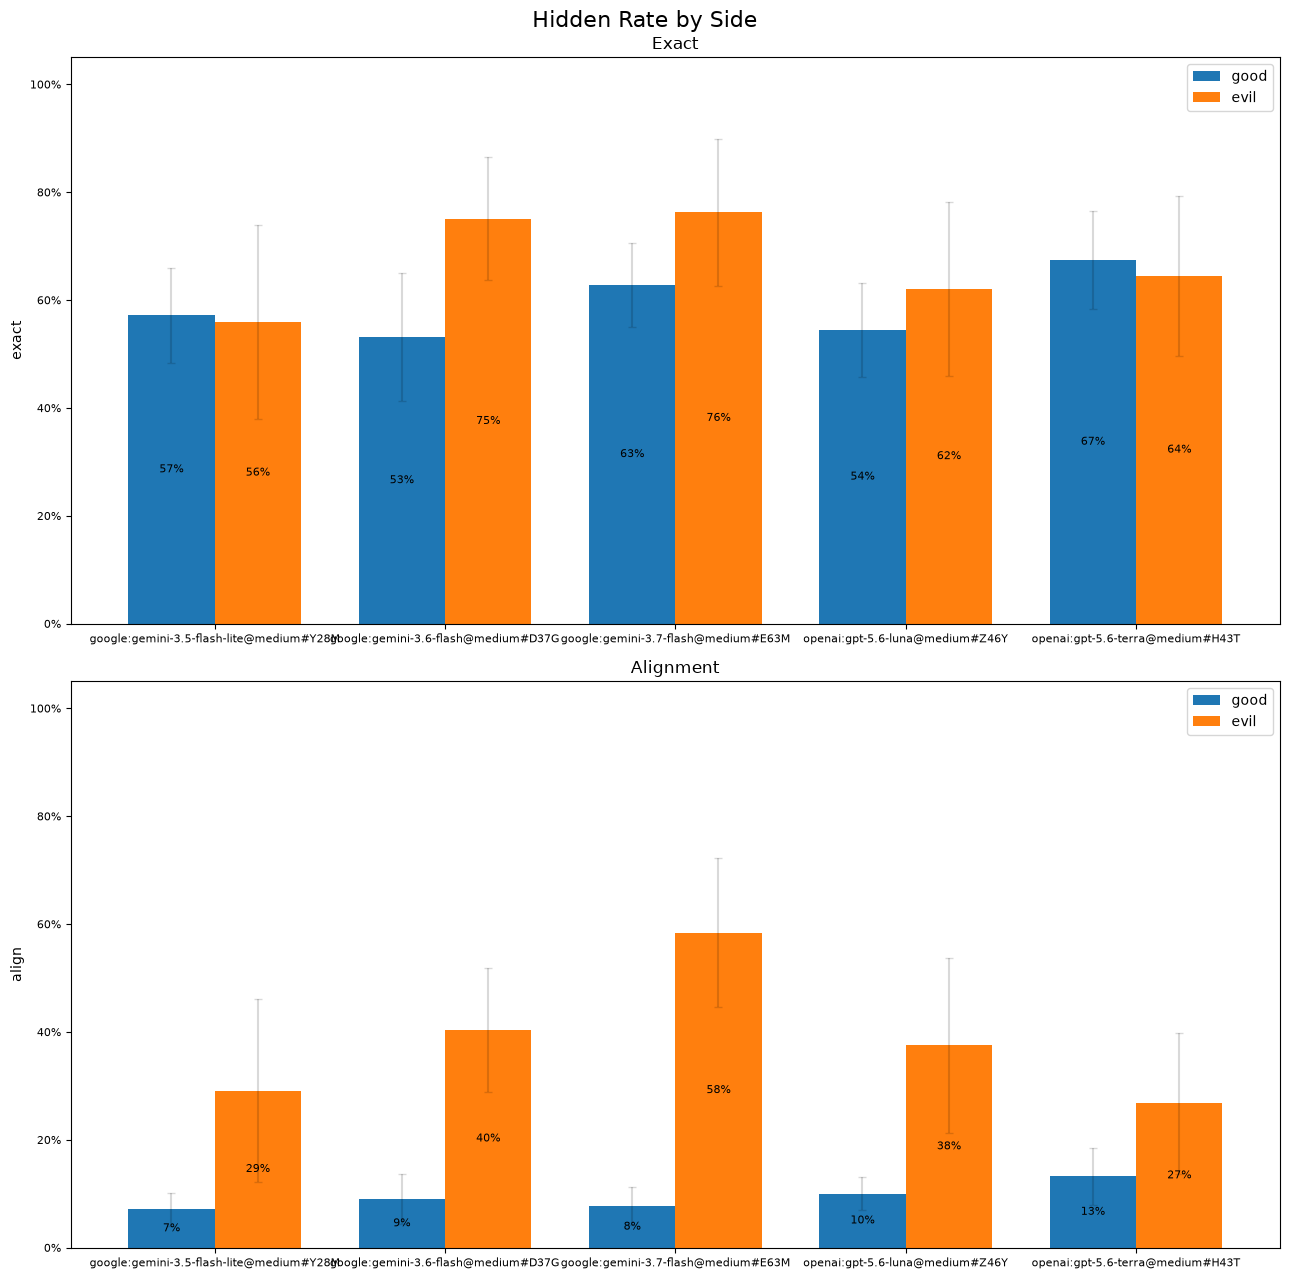

In [11]:
match_bars(hidden_rate(RUN_DIR, by="side"), "Hidden Rate by Side", grouped=True)

### **By Role**

Hidden rate split by the seat's own role (exact = precise role hidden, alignment = side hidden).

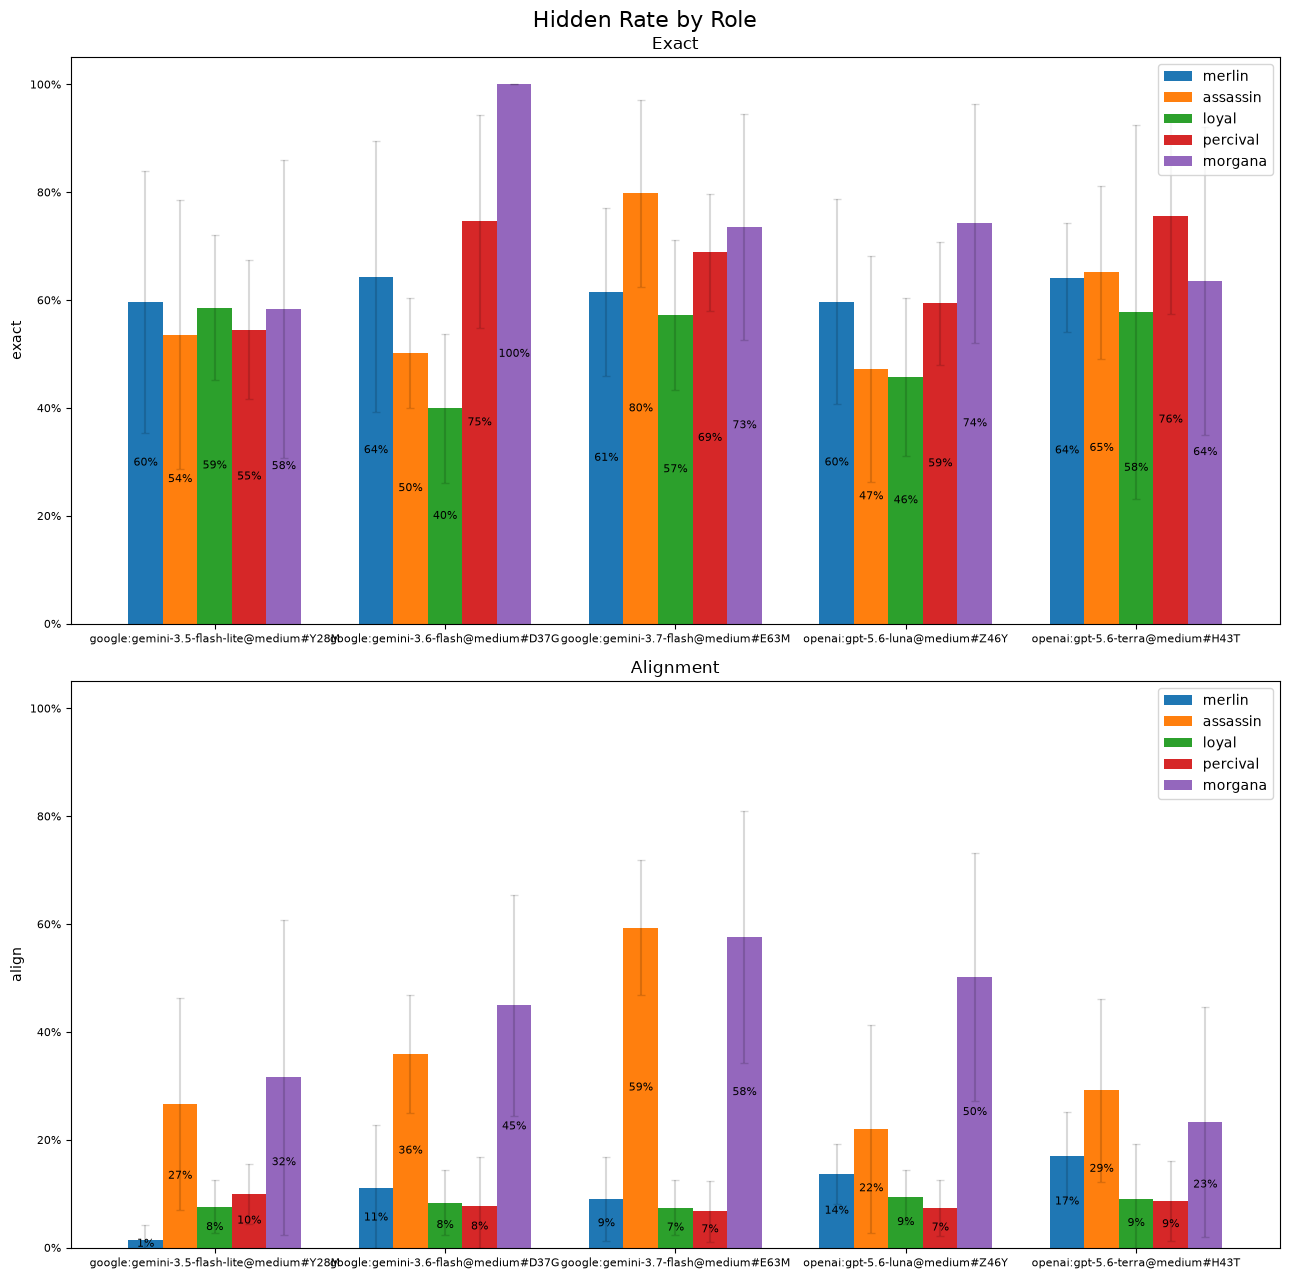

In [12]:
match_bars(hidden_rate(RUN_DIR, by="role"), "Hidden Rate by Role", grouped=True)

## **Assassination**
 
The end-game kill, per seat. Assassin accuracy is how often a seat correctly picked Merlin when it was the assassin. Merlin survival is how often a seat survived when it was Merlin. Only games that reached an assassination count, so samples are small.

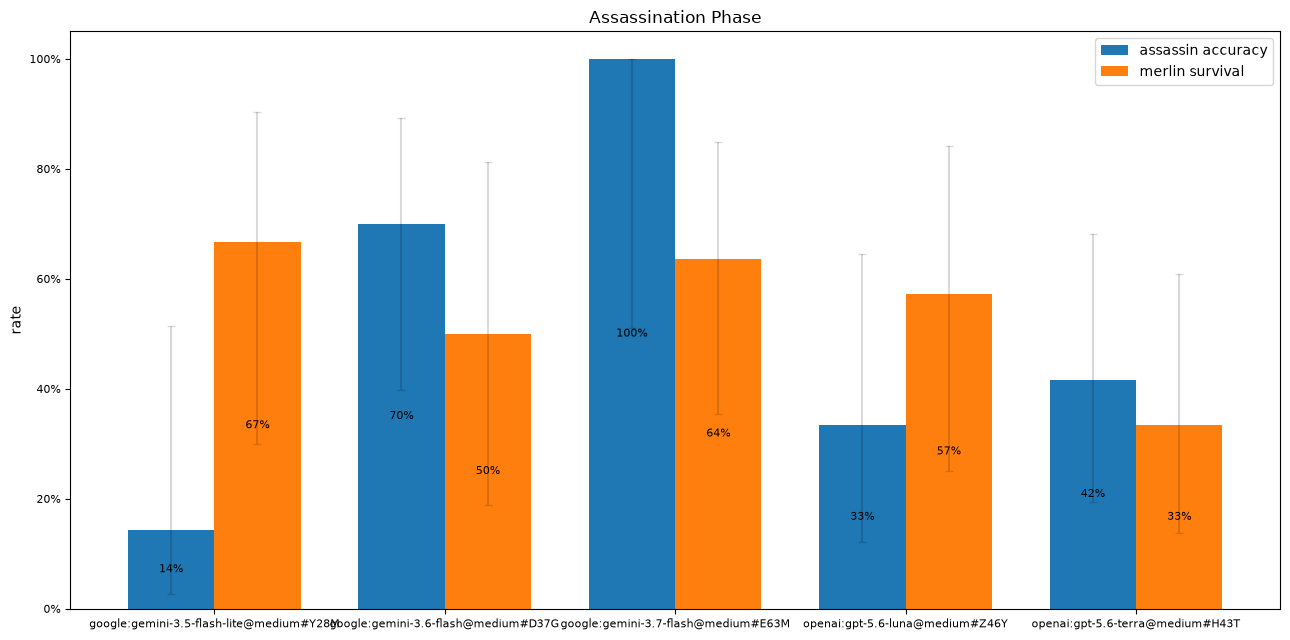

In [13]:
asn = assassination(RUN_DIR)
cols = {"assassin accuracy": "as_assassin", "merlin survival": "as_merlin"}
rates = pd.DataFrame(
  {label: {k: v[role]["rate"] for k, v in asn.items() if v.get(role)} for label, role in cols.items()}
).sort_index()
yerr = {
  label: [
    [rates.loc[k, label] - asn[k][role]["ci_low"] if k in asn and asn[k].get(role) else 0 for k in rates.index],
    [asn[k][role]["ci_high"] - rates.loc[k, label] if k in asn and asn[k].get(role) else 0 for k in rates.index],
  ]
  for label, role in cols.items()
}
bars(rates.fillna(0), "Assassination Phase", "rate", yerr=yerr)

## **Trajectories**
 
Each metric as a rolling mean over games (expanding, then sliding). An upward trend indicates improvement as the seat accumulates memory.
 
### **Helper**

In [14]:
def traj_frame(traj, field=None):
  """{seat: {overall: series}} -> DataFrame (rows=game index, cols=seat)."""
  cols = {}
  for seat, groups in sorted(traj.items()):
    series = groups.get("overall")
    if not series:
      continue
    cols[seat] = series[field] if isinstance(series, dict) else series
  return pd.DataFrame(cols)


def plot_traj(traj, field, title, ylabel, ax=None):
  own = ax is None
  ax = traj_frame(traj, field).plot(
    ax=ax, figsize=(13, 6.5) if own else None, marker=".", title=title, xlabel="game", ylabel=ylabel, ylim=(0, 1)
  )
  ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
  ax.grid(True, alpha=0.25)
  ax.legend(loc="upper left")
  if own:
    plt.tight_layout()
    plt.show()


def match_traj(traj, suptitle):
  """Two stacked trajectory panels: exact on top, align below."""
  fig, axes = plt.subplots(2, 1, figsize=(13, 13))
  fig.suptitle(suptitle)
  for ax, metric in zip(axes, ["exact", "align"]):
    plot_traj(traj, metric, {"exact": "Exact", "align": "Alignment"}[metric], metric, ax=ax)
  plt.tight_layout()
  plt.show()

### **Win Rate**

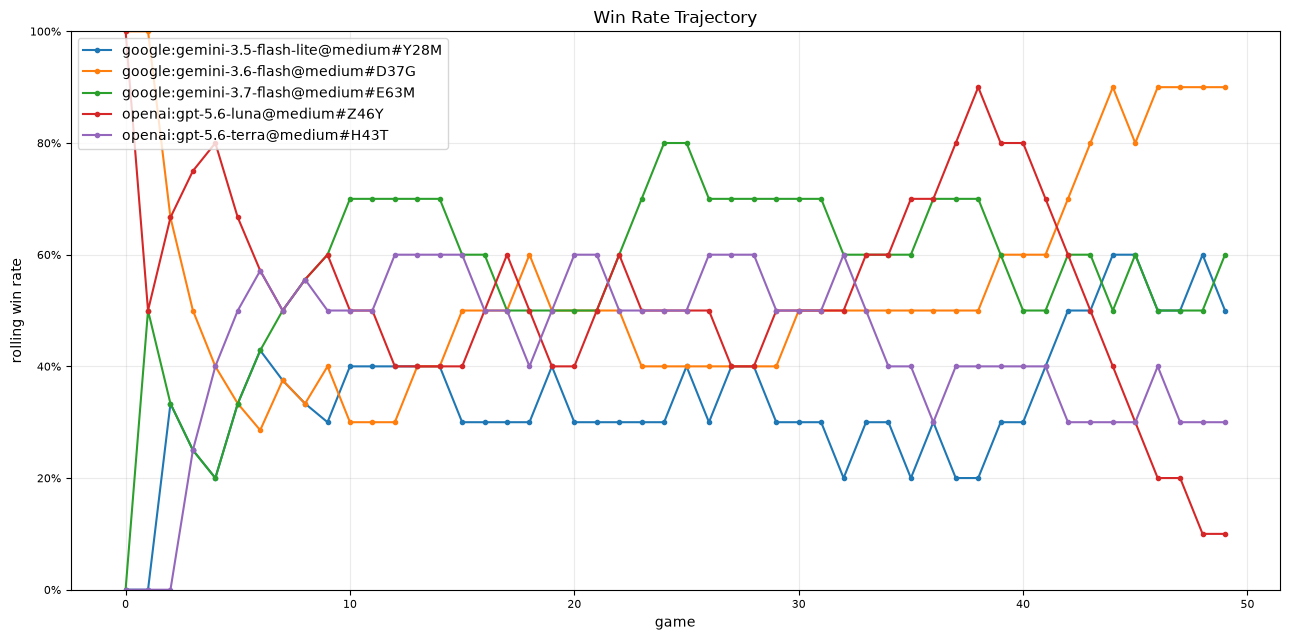

In [15]:
plot_traj(win_rate_trajectory(RUN_DIR, window=WINDOW), None, "Win Rate Trajectory", "rolling win rate")

### **Guess Accuracy**

Exact-role and alignment guess accuracy over the run, in separate panels.

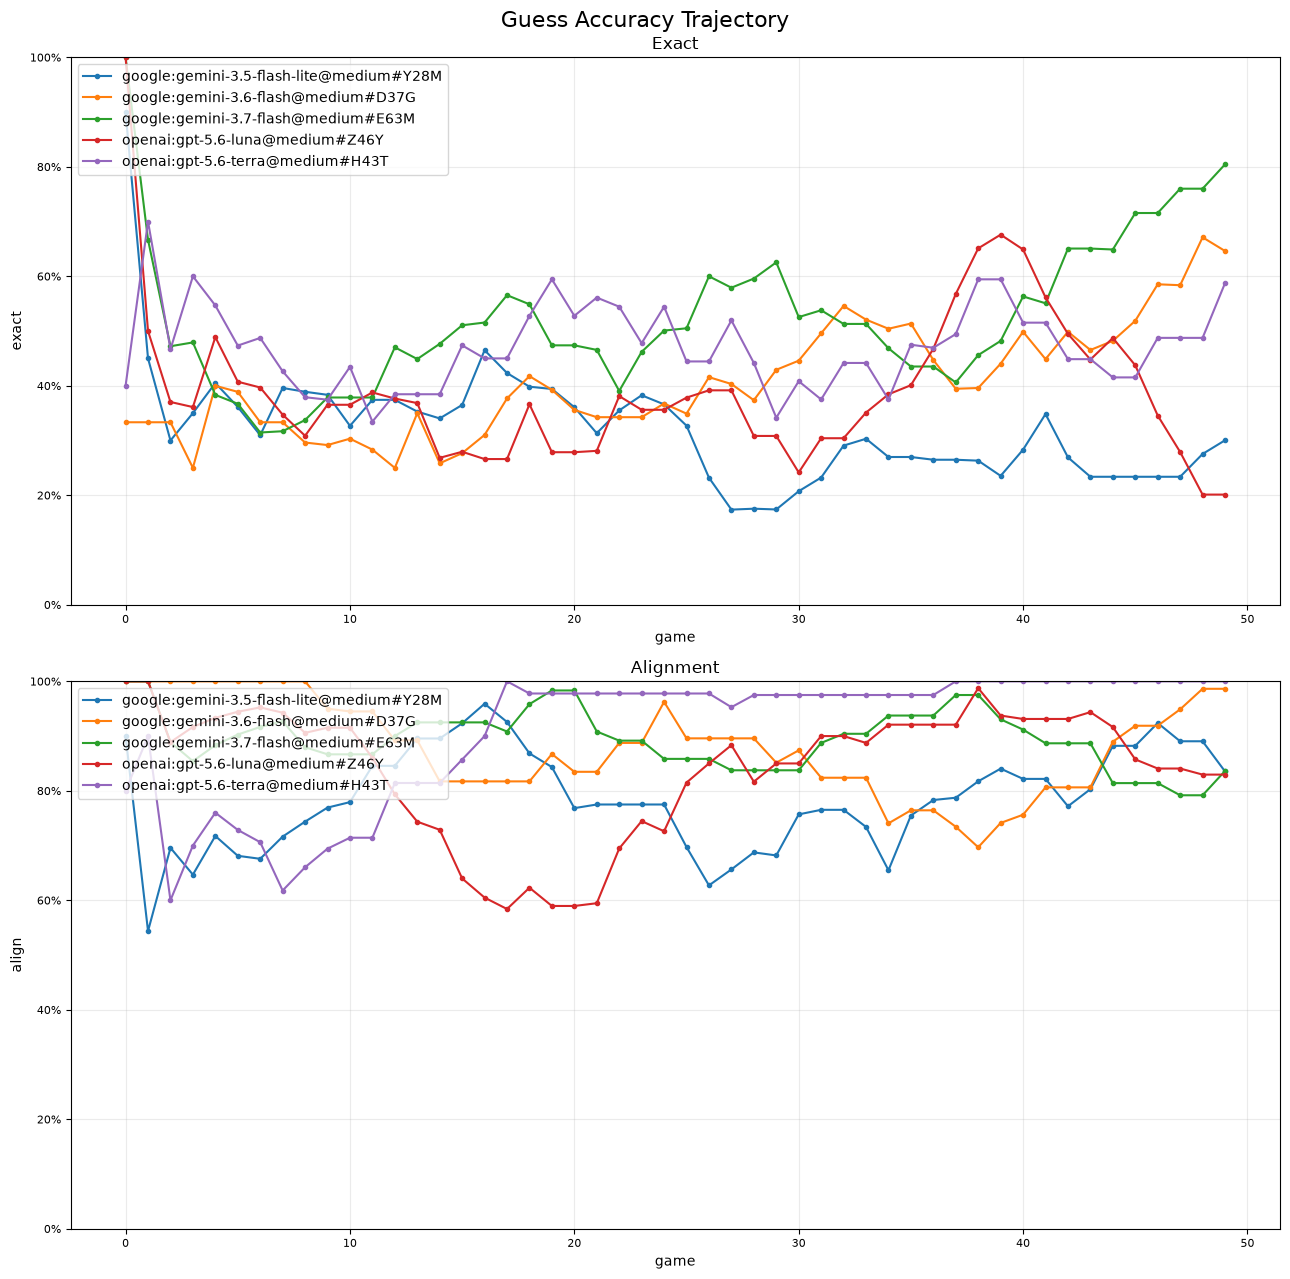

In [16]:
match_traj(belief_accuracy_trajectory(RUN_DIR, window=WINDOW), "Guess Accuracy Trajectory")

### **Hidden Rate**

Exact-role and alignment concealment over the run, in separate panels.


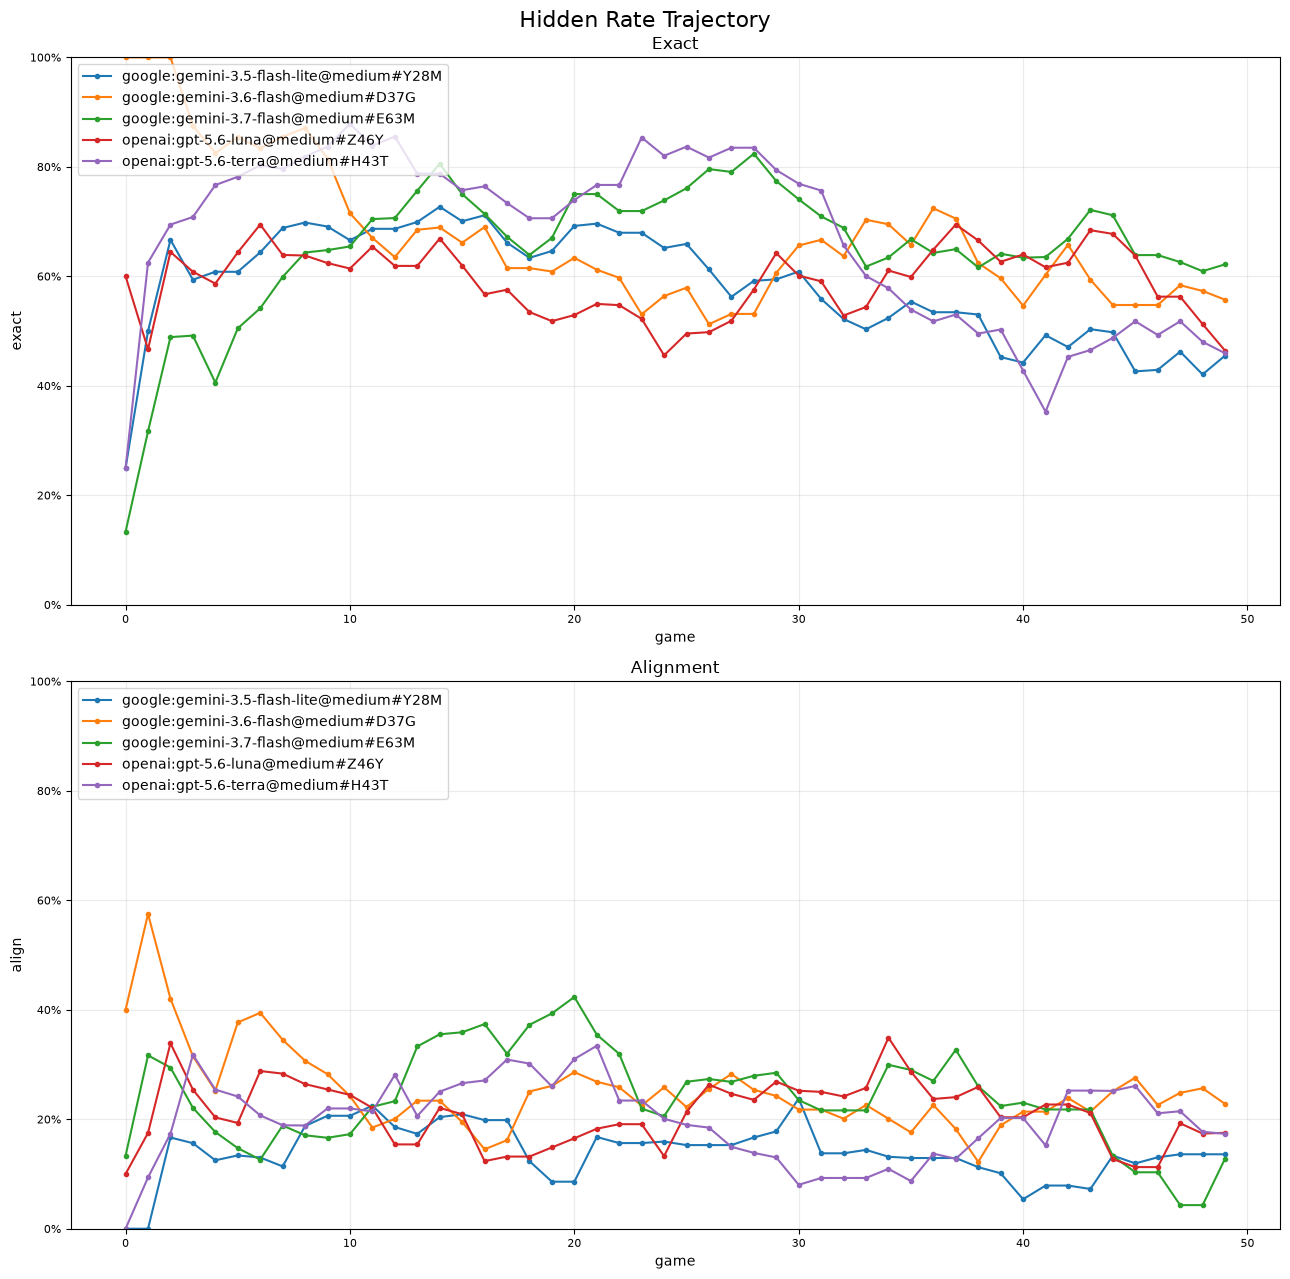

In [17]:
match_traj(hidden_rate_trajectory(RUN_DIR, window=WINDOW), "Hidden Rate Trajectory")